<a href="https://colab.research.google.com/github/anupsubbu98/Kaggle-Competitions/blob/main/Song_Popularity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('spotify_dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.shape

(114000, 21)

In [5]:
artists = pd.DataFrame(df['artists'].unique())
artists

,0
0,Gen Hoshino
1,Ben Woodward
2,Ingrid Michaelson;ZAYN
3,Kina Grannis
4,Chord Overstreet
...,...
31433,Paz Interior
31434,Bethel Music;Molly Skaggs
31435,Cuencos Tibetanos Sonidos Relajantes
31436,Bryan & Katie Torwalt;Brock Human


In [6]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 113999 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          11

In [9]:
df['duration_ms'] = df['duration_ms']/1000

In [10]:
df = df.rename(columns = {'duration_ms':'duration_sec'})

In [11]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_sec,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230.666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149.610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210.826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201.933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198.853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [12]:
df.describe()

,Unnamed: 0,popularity,duration_sec,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,228.031153,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,107.296058,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,174.066000,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,212.906000,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,261.506000,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5237.295000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [13]:
df['popularity'].mean()

33.23882665637418

In [14]:
df['popularity_flag'] = 0

In [15]:
df.loc[df['popularity'] > 50, 'popularity_flag'] = 1

In [16]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_sec,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_flag
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230.666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,1
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149.610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,1
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210.826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,1
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201.933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198.853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1


In [17]:
artists_df = pd.DataFrame(df.groupby('artists').size())
artists_df.sort_values(by=[0], ascending=False).head(15)

,0
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
Prateek Kuhad,217
Feid,202
Chuck Berry,190
Håkan Hellström,183


In [18]:
albums_df = pd.DataFrame(df.groupby('album_name').size())
albums_df.sort_values(by=[0], ascending=False).head(15)

,0
album_name,
Alternative Christmas 2022,195
Feliz Cumpleaños con Perreo,184
Metal,143
Halloween con perreito,123
Halloween Party 2022,115
The Complete Hank Williams,111
Fiesta portatil,110
Frescura y Perreo,106
Esto me suena a Farra,105


In [19]:
track_df = pd.DataFrame(df.groupby('track_name').size())
track_df.sort_values(by=[0], ascending=False).head(15)

,0
track_name,
Run Rudolph Run,151
Halloween,88
Frosty The Snowman,81
Little Saint Nick - 1991 Remix,76
Last Last,75
Christmas Time,72
CÓMO SE SIENTE - Remix,64
Sleigh Ride,61
RUMBATÓN,60


In [20]:
df1 = df.drop(columns={'Unnamed: 0',	'track_id',	'artists',	'album_name',	'track_name',	'popularity'},axis=1)

In [21]:
df1.head()

,duration_sec,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_flag
0,230.666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,1
1,149.610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,1
2,210.826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,1
3,201.933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1
4,198.853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1


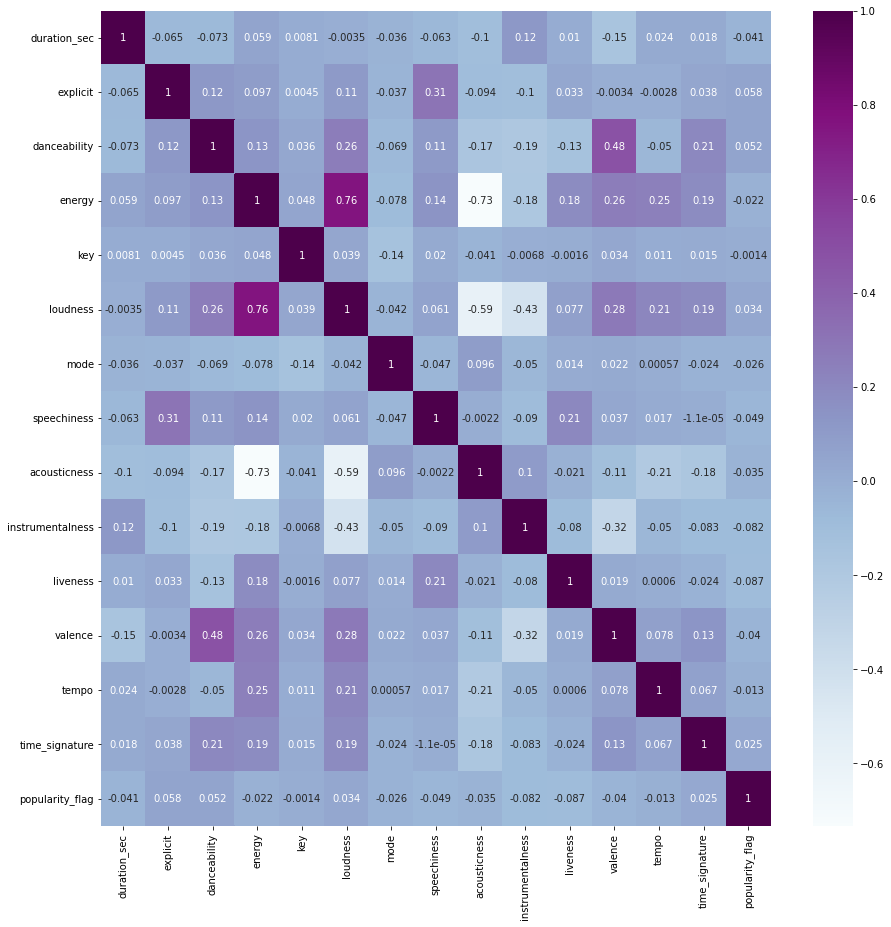

In [22]:
plt.figure(figsize=(15,15))
sns.heatmap(df1.corr(),annot=True,cmap = "BuPu")
plt.show()

In [23]:
pop_corr = pd.DataFrame(df1.corr()['popularity_flag'])
pop_corr

,popularity_flag
duration_sec,-0.040975
explicit,0.057928
danceability,0.052040
energy,-0.022273
key,-0.001432
loudness,0.034286
mode,-0.026229
speechiness,-0.049383
acousticness,-0.035401
instrumentalness,-0.081801


In [24]:
pop_corr_list = pop_corr['popularity_flag'].tolist()
pop_corr_list

[-0.040974600318825875,
 0.05792779763106764,
 0.0520399071149888,
 -0.02227318888486478,
 -0.0014317298945297657,
 0.034285500399002355,
 -0.02622924483421693,
 -0.04938329611752406,
 -0.03540075726398946,
 -0.08180059663739617,
 -0.08690805262313654,
 -0.04023874549997669,
 -0.013157555977091924,
 0.024892189281027637,
 1.0]

In [25]:
pop_corr_abs = []
for ele in pop_corr_list:
     pop_corr_abs.append(abs(ele))

pop_corr_abs

[0.040974600318825875,
 0.05792779763106764,
 0.0520399071149888,
 0.02227318888486478,
 0.0014317298945297657,
 0.034285500399002355,
 0.02622924483421693,
 0.04938329611752406,
 0.03540075726398946,
 0.08180059663739617,
 0.08690805262313654,
 0.04023874549997669,
 0.013157555977091924,
 0.024892189281027637,
 1.0]

In [26]:
avg = np.average(pop_corr_abs[0:-1])
avg

0.040495940176974186

In [27]:
pop_corr['popularity_flag_abs'] = pop_corr_abs
pop_corr

,popularity_flag,popularity_flag_abs
duration_sec,-0.040975,0.040975
explicit,0.057928,0.057928
danceability,0.052040,0.052040
energy,-0.022273,0.022273
key,-0.001432,0.001432
loudness,0.034286,0.034286
mode,-0.026229,0.026229
speechiness,-0.049383,0.049383
acousticness,-0.035401,0.035401
instrumentalness,-0.081801,0.081801


In [28]:
pop_corr_gt_avg = pop_corr[pop_corr['popularity_flag_abs']>avg].sort_values(by = 'popularity_flag_abs',ascending=False)
pop_corr_gt_avg[1:]

,popularity_flag,popularity_flag_abs
liveness,-0.086908,0.086908
instrumentalness,-0.081801,0.081801
explicit,0.057928,0.057928
danceability,0.052040,0.052040
speechiness,-0.049383,0.049383
duration_sec,-0.040975,0.040975


In [29]:
artists_df = pd.DataFrame(df.groupby('artists').size()).reset_index()
albums_df  = pd.DataFrame(df.groupby('album_name').size()).reset_index()

In [30]:
top_15_artists = pd.DataFrame()
top_15_artists['Artists'] = pd.DataFrame(artists_df.sort_values(by=[0], ascending=False)['artists'].head(15))
top_15_artists['Count']   = pd.DataFrame(artists_df.sort_values(by=[0], ascending=False)[0].head(15))
top_15_artists.reset_index(level=None, drop=False, inplace=True, col_level=0, col_fill='')
top_15_artists.drop(columns={'index'},inplace=True)

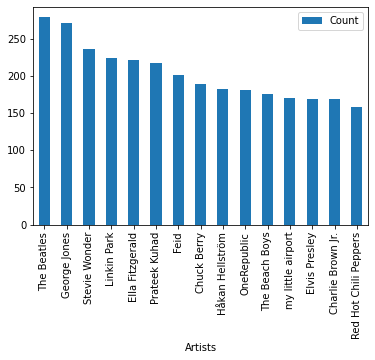

In [31]:
top_15_artists.plot(x='Artists',kind='bar')

In [32]:
top_15_albums = pd.DataFrame()
top_15_albums['Albums']   = pd.DataFrame(albums_df.sort_values(by=[0], ascending=False)['album_name'].head(15))
top_15_albums['Count']   = pd.DataFrame(albums_df.sort_values(by=[0], ascending=False)[0].head(15))
top_15_albums.reset_index(level=None, drop=False, inplace=True, col_level=0, col_fill='')
top_15_albums.drop(columns={'index'},inplace=True)  

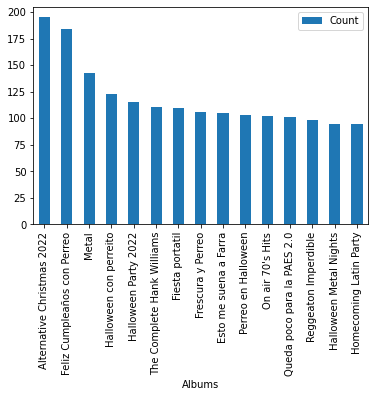

In [33]:
top_15_albums.plot(x='Albums',kind='bar')

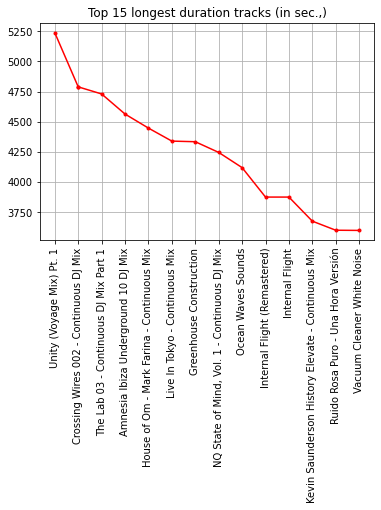

In [34]:
df.sort_values('duration_sec', axis = 0, ascending = False,inplace = True)
plt.plot(df['track_name'].head(15),df['duration_sec'].head(15),marker='.',color='r')
plt.xticks(rotation = 'vertical')
plt.title('Top 15 longest duration tracks (in sec.,)')
plt.grid()

In [35]:
cols = ['explicit','track_genre'] 
dummy_df = pd.get_dummies(df1,columns = cols)
pd.set_option('display.max_columns', None)
dummy_df.head()

,duration_sec,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity_flag,explicit_False,explicit_True,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,230.666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,149.610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,210.826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,201.933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,198.853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [36]:
X = dummy_df.drop(['popularity_flag'],axis=1)
Y = dummy_df['popularity_flag']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.85, random_state=12345)
X_train.shape, X_test.shape

((96899, 129), (17100, 129))

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()
rf.fit(X_train, Y_train)
rf.score(X_train, Y_train)

0.9929101435515331

In [39]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5,test_size=0.2)
cross_val_score(RandomForestClassifier(),X,Y,cv=cv)

array([0.84065789, 0.83171053, 0.83403509, 0.84109649, 0.83346491])

In [40]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV

def best_model(X,Y):
    algos = {
    
       'Linear Regression' :
         {
            'model' : LinearRegression(),
            'params': {
                'normalize' : [True,False]
                      }
         },

         'Logistic Regression' : 
         {
            'model': LogisticRegression(solver='liblinear',multi_class='auto'),
            'params': {
                'C': [1,5,10]
                      }
         },

         'Lasso' : 
         {
            'model' : Lasso(),
            'params': {
                'alpha' : [1,2],
                'selection' : ['random','cyclic']
                } 
         },
                  
        

        #  'Decision Tree' : 
        #  {
        #     'model' : DecisionTreeClassifier(),
        #     'params':{
        #         'criterion' : ['mse','friedman_mse'],
        #         'splitter'  : ['best','random']
        #         }
        #  },
        
        'Random Forest': 
         {
            'model': RandomForestClassifier(),
            'params' : {
                'max_depth': [80, 100],
                'max_features': ['auto', 'sqrt'],
                'min_samples_leaf': [1,3, 5],
                'min_samples_split': [2, 8, 10],
                'n_estimators': [1,5,10,100, 500,1000]
                       }
         },

         'SVM': 
         {
            'model': svm.SVC(gamma='auto',probability=True),
            'params' : {
                'C': [1,10,100,1000],
                'kernel': ['rbf','linear']
                       }  
         }
    } 

    scores = []
    cv = ShuffleSplit(n_splits=5,test_size=0.2)
    for algo_name, config in algos.items():
      gs = GridSearchCV(config['model'],config['params'],cv=cv,return_train_score = False)
      gs.fit(X,Y)
      scores.append({
            'Model' : algo_name,
            'Best Score' : gs.best_score_,
            'Best Params' : gs.best_params_
       })
    return pd.DataFrame(scores,columns=['Model','Best Score','Best Params'])

best_model(X,Y)

[[73102   189]
 [  498 23110]]
[[12322   616]
 [ 2056  2106]]


Text(33.0, 0.5, 'Actual')

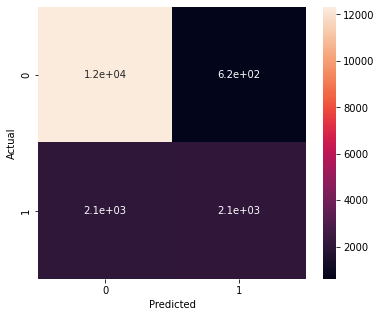

In [41]:
from sklearn.metrics import confusion_matrix

Y_train_pred  = rf.predict(X_train)
Y_test_pred   = rf.predict(X_test)

conf_train_df = pd.DataFrame()
conf_test_df  = pd.DataFrame()

Y_train_pred_df = pd.DataFrame(Y_train_pred)
conf_train_df['Y_train'] = Y_train
conf_train_df['Y_train_pred'] = Y_train_pred_df

Y_test_pred_df = pd.DataFrame(Y_test_pred)
conf_test_df['Y_test'] = Y_test
conf_test_df['Y_test_pred'] = Y_test_pred_df

cm_train = confusion_matrix(Y_train,Y_train_pred)
cm_test  = confusion_matrix(Y_test,Y_test_pred)

print(cm_train)
print(cm_test)

plt.figure(figsize = (6,5))
sns.heatmap(cm_test,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [42]:
accuracy  = (cm_test[0,0]+cm_test[1,1]) / (cm_test[0,0]+cm_test[1,1]+cm_test[0,1]+cm_test[1,0])
precision = (cm_test[0,0]) / (cm_test[0,0]+cm_test[0,1])
recall    = (cm_test[0,0]) / (cm_test[0,0]+cm_test[1,0])

print("Accuracy : ", accuracy)
print("Precision: ", precision)
print("Recall   : ", recall)

Accuracy :  0.8437426900584796
Precision:  0.9523883134951306
Recall   :  0.857003755737933


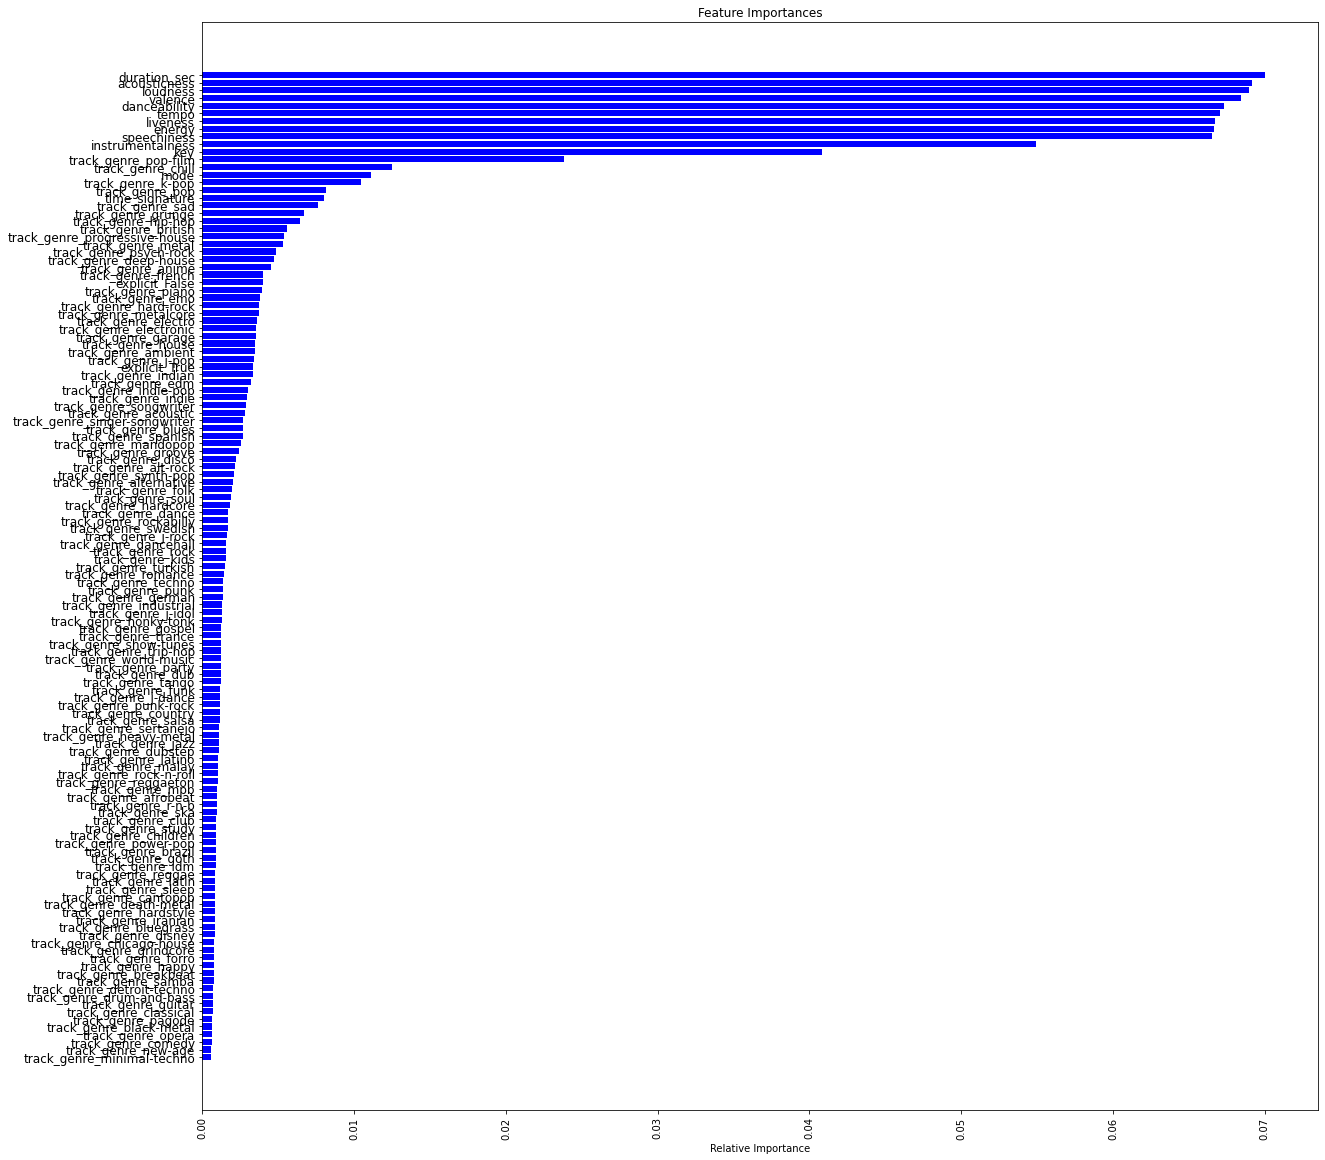

In [43]:
#Feature Importance

feature_names = X.columns
target_names = df['popularity_flag'].astype('category').unique().tolist()

importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(20,20))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel('Relative Importance')
plt.xticks(rotation = 'vertical')
plt.show()